<a href="https://colab.research.google.com/github/kimjiwoo2/Pill-agent/blob/develop/notebooks/%EC%A1%B0%EC%9C%A4%EC%88%98/ys_easyOCR_baseline_0601.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pill Imprint OCR — EasyOCR Baseline (revised)

### ① 데이터 준비
| 단계 | 설명 |
|---|---|
| Manifest 로드 | `bbox_manifest_val_with_attributes.csv` 읽기 |
| OCR 후보 필터링 | `has_print=True` + `dataset_type=single` + `split=val` |
| Target 레이블 생성 | `drug_dir` 기반으로 앞/뒷면 분기 → `target_text`, `target_candidates` |

### ② 이미지 전처리
| 단계 | 설명 |
|---|---|
| 이미지 경로 resolve | `split` 컬럼 기반 경로 조합, 없는 이미지 스킵 |
| 공통 전처리 | Gray World AWB + bilateral denoise |
| BBox Crop | manifest bbox + margin 16% → crop, CLAHE로 각인 대비 보정 |

### ③ OCR 및 평가
| 단계 | 설명 |
|---|---|
| EasyOCR 실행 | `en+ko`, beamsearch decoder, 결과 합쳐 `pred_text` |
| 예측값 정규화 | `normalize_prediction()` — 대문자, 허용 문자 필터 |
| Metrics | Exact Match (후보 중 하나 일치) + CER (Levenshtein 기반) |

> **target_text 설계**: `print_front/back` 원본은 타겟으로 직접 쓰지 않음.
> `drug_dir='앞면'`이면 `print_front`만, `'뒷면'`이면 `print_back`만 정답으로 사용.
> `drug_dir`이 없거나 불명확하면 `front/back` 둘 다 후보로 관리 (`target_candidates`).


## 0. Colab setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install easyocr opencv-python-headless pandas numpy matplotlib tqdm rapidfuzz pillow-heif
!pip -q install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.0 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.auto import tqdm


## 1. Paths

In [4]:
ZIP_PATH = "/content/drive/MyDrive/Pillot/dataset/pilliot_15k_optimized_leakage_free_split.zip"
!unzip -q "{ZIP_PATH}" -d /content

In [5]:
DATA_ROOT = Path("/content/pilliot_15k_optimized_leakage_free_split")

MANIFEST_DIR = DATA_ROOT / "manifests"
IMAGE_ROOT   = DATA_ROOT / "images"

WORK_DIR   = Path("/content/pillot_ocr_work")
CROP_DIR   = WORK_DIR / "crops"
RESULT_DIR = WORK_DIR / "results"

for d in [WORK_DIR, CROP_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


## 2. Manifest loading & target 레이블 정의

In [25]:
IGNORE_IMPRINT_TOKENS = {
    "", "NAN", "NONE", "NULL", "마크", "분할선", "없음", "무", "-",
}


def normalize_imprint(text: object, keep_separator: bool = False) -> str:
    """각인 라벨/예측값을 비교 가능한 형태로 정규화.
    - NaN, 비문자 토큰 → ''
    - 대문자 변환, 공백 제거, 허용 문자 외 제거
    """
    if pd.isna(text):
        return ""
    text = str(text).strip()
    if text.upper() in IGNORE_IMPRINT_TOKENS:
        return ""
    text = text.upper()
    text = re.sub(r"\s+", "", text)
    text = text.replace("분할선", "").replace("마크", "")
    allowed = r"[^0-9A-Z가-힣+\-/|]" if keep_separator else r"[^0-9A-Z가-힣+\-/]"
    text = re.sub(allowed, "", text)
    if text.upper() in IGNORE_IMPRINT_TOKENS:
        return ""
    return text


def build_target_for_row(row: pd.Series) -> dict:
    """
    한 행의 정답 정보를 계산합니다.

    drug_dir 컬럼이 있으면:
      - '앞면' → print_front만 정답
      - '뒷면' → print_back만 정답
    drug_dir이 없거나 알 수 없으면:
      - front/back 둘 다 후보 → target_text = 'FRONT/BACK'
    """
    front = normalize_imprint(row.get("print_front", ""))
    back  = normalize_imprint(row.get("print_back",  ""))

    # drug_dir 우선 활용
    drug_dir = str(row.get("drug_dir", "")).strip()
    if drug_dir == "앞면" and front:
        target = front
        candidates = [front]
    elif drug_dir == "뒷면" and back:
        target = back
        candidates = [back]
    else:
        # drug_dir 없거나 모호한 경우 → 후보 방식
        candidates = [t for t in [front, back] if t]
        candidates = list(dict.fromkeys(candidates))  # dedup 순서 유지
        target = "/".join(candidates)

    return {
        "target_text_front": front,   # 표시용 (앞면 정규화값)
        "target_text_back":  back,    # 표시용 (뒷면 정규화값)
        "target_candidates": candidates,
        "target_text":       target,
    }


def normalize_prediction(text: object) -> str:
    return normalize_imprint(text, keep_separator=True)


def load_manifest(data_root: Path,
                  manifest_name: str = "bbox_manifest_all_with_attributes.csv") -> pd.DataFrame:
    path = data_root / "manifests" / manifest_name
    if not path.exists():
        raise FileNotFoundError(f"Manifest not found: {path}")
    df = pd.read_csv(path, low_memory=False)
    required = {"dataset_type", "split_type", "image_file"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    return df


def filter_ocr_candidates(
    df: pd.DataFrame,
    split: Optional[str] = "val",
    dataset_type: Optional[str] = "single",
    limit: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    OCR 평가 후보 필터링.

    """
    out = df.copy()

    if "for_ocr_eval_candidate" in out.columns:
        out = out[out["for_ocr_eval_candidate"].astype(str).str.lower().eq("true")]
    if "has_print" in out.columns:
        out = out[out["has_print"].astype(str).str.lower().eq("true")]
    if split:
        out = out[out["split_type"].eq(split)]
    if dataset_type:
        out = out[out["dataset_type"].eq(dataset_type)]

    # If 'out' is empty after filtering, ensure target columns are added with appropriate types.
    if out.empty:
        # Define expected columns for the target_cols, even if empty
        empty_target_cols = pd.DataFrame(columns=[
            "target_text_front", "target_text_back", "target_candidates", "target_text"
        ])
        # Concatenate with the original (empty) 'out' to get an empty DataFrame with the columns
        out = pd.concat([out, empty_target_cols], axis=1)
        # Return early as there's nothing to process further
        return out.reset_index(drop=True)

    # target 컬럼 계산 (drug_dir 활용)
    target_cols = out.apply(build_target_for_row, axis=1, result_type="expand")
    out = pd.concat([out, target_cols], axis=1)
    out = out[out["target_text"].ne("")]

    if limit:
        import random
        random.seed(seed)
        groups = out.groupby("item_seq")
        all_kinds = list(groups.groups.keys())
        random.shuffle(all_kinds)
        selected, total = [], 0
        for kind in all_kinds:
            count = len(groups.get_group(kind))
            if total + count > limit:
                continue
            selected.append(kind)
            total += count
            if total >= limit * 0.9:
                break
        out = out[out["item_seq"].isin(selected)]

    return out.reset_index(drop=True)


df_val  = load_manifest(DATA_ROOT, manifest_name="bbox_manifest_val_with_attributes.csv")
df_eval = filter_ocr_candidates(df_val, split= None, dataset_type="single", limit=500)
print(f"전체: {df_all.shape}, 평가셋: {df_eval.shape}")
display(df_eval[["image_file", "target_text_front", "target_text_back", "target_text"]])


전체: (23517, 40), 평가셋: (454, 44)


,image_file,target_text_front,target_text_back,target_text
0,K-012757_0_2_0_0_75_320_200.png,JW3,,JW3
1,K-012757_0_2_0_1_75_000_200.png,JW3,,JW3
2,K-012757_0_2_0_1_75_260_200.png,JW3,,JW3
3,K-012757_0_2_0_2_75_220_200.png,JW3,,JW3
4,K-012757_0_2_0_2_75_280_200.png,JW3,,JW3
...,...,...,...,...
449,K-035811_0_0_1_0_90_100_200.png,UK,OC375,UK/OC375
450,K-035811_0_0_1_0_90_220_200.png,UK,OC375,UK/OC375
451,K-035811_0_0_1_0_90_300_200.png,UK,OC375,UK/OC375
452,K-035811_0_0_1_1_90_060_200.png,UK,OC375,UK/OC375


**target_text 구조 설명:**
- `target_text_front` / `target_text_back`: 각각 `normalize_imprint(print_front/back)`. 표시/디버깅용.
- `target_text`: 실제 평가 기준. `drug_dir`이 '앞면'이면 front만, '뒷면'이면 back만. 모를 땐 `FRONT/BACK` 형태.
- `target_candidates`: 평가 시 "후보 중 하나와 일치하면 정답"으로 사용.


## 3. Image path resolving

In [26]:
def _zip_stem(name: str) -> str:
    return Path(str(name)).stem


def resolve_image_path(row: pd.Series, data_root: Path = DATA_ROOT) -> Path:
    """
    수정: split_type 대신 split 컬럼 우선 사용.
    이전 버전은 split_type으로 경로를 만들었으나, 실제 파일은 split(train/val) 기준으로 저장되어
    경로 불일치로 184/471개 이미지를 찾지 못하는 문제가 있었음.
    split 컬럼 없으면 split_type 폴백.
    """
    split_col      = row.get("split") or row.get("split_type", "train")
    dataset_type   = str(row["dataset_type"])
    image_zip_stem = _zip_stem(row["image_zip_name"])
    image_file     = str(row["image_file"])
    return data_root / "images" / str(split_col) / dataset_type / image_zip_stem / image_file


def report_missing_images(df: pd.DataFrame, n: int = 10) -> None:
    paths = df.apply(resolve_image_path, axis=1)
    missing = [not p.exists() for p in paths]
    print(f"이미지 확인: {sum(not m for m in missing)} 존재 / {sum(missing)} 누락 (총 {len(df)})")
    if any(missing):
        print("누락 zip 목록:")
        print(df[missing]["image_zip_name"].value_counts().head(n))


report_missing_images(df_eval)


이미지 확인: 454 존재 / 0 누락 (총 454)


## 4. 공통 전처리

In [27]:
@dataclass
class CommonPreprocessConfig:
    apply_awb: bool = True
    denoise_method: str = "bilateral"  # "none" | "bilateral" | "nlm"
    bilateral_d: int = 5
    bilateral_sigma_color: int = 35
    bilateral_sigma_space: int = 35
    nlm_h: int = 3
    target_size: int = 640
    pad_color: tuple[int, int, int] = (114, 114, 114)
    normalize_pixels: bool = False


def read_bgr(path: Path) -> np.ndarray:
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in {".heic", ".heif"}:
        try:
            import pillow_heif
            from PIL import Image
            pillow_heif.register_heif_opener()
            rgb = np.array(Image.open(path).convert("RGB"))
            return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        except ImportError as exc:
            raise ImportError("pillow-heif 필요: pip install pillow-heif") from exc
    image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise FileNotFoundError(path)
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    if image.shape[2] == 4:
        return cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    return image


def gray_world_awb_bgr(image_bgr: np.ndarray) -> np.ndarray:
    image = image_bgr.astype(np.float32)
    means = image.reshape(-1, 3).mean(axis=0)
    gray_mean = means.mean()
    scale = gray_mean / np.maximum(means, 1e-6)
    return np.clip(image * scale, 0, 255).astype(np.uint8)


def denoise_bgr(image_bgr: np.ndarray, cfg: CommonPreprocessConfig) -> np.ndarray:
    if cfg.denoise_method == "none":
        return image_bgr
    if cfg.denoise_method == "bilateral":
        return cv2.bilateralFilter(image_bgr, cfg.bilateral_d,
                                   cfg.bilateral_sigma_color, cfg.bilateral_sigma_space)
    if cfg.denoise_method == "nlm":
        return cv2.fastNlMeansDenoisingColored(image_bgr, None, cfg.nlm_h, cfg.nlm_h, 7, 21)
    raise ValueError(f"Unknown denoise_method: {cfg.denoise_method}")


def common_preprocess_bgr(
    image_bgr: np.ndarray,
    cfg: CommonPreprocessConfig = CommonPreprocessConfig(),
    do_letterbox: bool = False,
) -> np.ndarray:
    out = image_bgr
    if cfg.apply_awb:
        out = gray_world_awb_bgr(out)
    out = denoise_bgr(out, cfg)
    return out


## 5. bbox 기반 알약 crop 생성 및 2차 OCR 전처리

In [28]:
@dataclass
class CropConfig:
    margin_ratio: float = 0.16
    min_size: int = 96
    target_size: int = 384
    use_bbox: bool = True
    apply_common_preprocess: bool = True


def crop_with_bbox(image_bgr: np.ndarray, row: pd.Series, cfg: CropConfig) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    if not cfg.use_bbox or any(pd.isna(row.get(k)) for k in ["bbox_x","bbox_y","bbox_w","bbox_h"]):
        return image_bgr
    x, y, bw, bh = [float(row[k]) for k in ["bbox_x","bbox_y","bbox_w","bbox_h"]]
    margin = cfg.margin_ratio * max(bw, bh)
    x1 = max(0, int(round(x - margin)))
    y1 = max(0, int(round(y - margin)))
    x2 = min(w, int(round(x + bw + margin)))
    y2 = min(h, int(round(y + bh + margin)))
    crop = image_bgr[y1:y2, x1:x2]
    return image_bgr if min(crop.shape[:2]) < cfg.min_size else crop


def enhance_crop_for_ocr_bgr(image_bgr: np.ndarray, target_size: int = 384) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    scale = target_size / max(h, w)
    if scale != 1:
        image_bgr = cv2.resize(image_bgr, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return cv2.cvtColor(clahe.apply(gray), cv2.COLOR_GRAY2BGR)


def make_crop(
    row: pd.Series,
    crop_cfg: CropConfig = CropConfig(),
    preprocess_cfg: CommonPreprocessConfig = CommonPreprocessConfig(),
) -> np.ndarray:
    path = resolve_image_path(row)
    image_bgr = read_bgr(path)
    if crop_cfg.apply_common_preprocess:
        image_bgr = common_preprocess_bgr(image_bgr, preprocess_cfg)
    return enhance_crop_for_ocr_bgr(crop_with_bbox(image_bgr, row, crop_cfg), crop_cfg.target_size)


def save_eval_crops(df: pd.DataFrame, out_dir: Path = CROP_DIR, limit: Optional[int] = None) -> pd.DataFrame:
    rows = df.head(limit).copy() if limit else df.copy()
    records, skip_reasons = [], []

    for idx, row in tqdm(rows.iterrows(), total=len(rows), desc="cropping"):
        try:
            crop_bgr = make_crop(row)
            safe_name = str(row["image_file"]).replace("/", "_").replace("\\", "_")
            out_path = out_dir / f"{idx:06d}_{safe_name}"
            cv2.imwrite(str(out_path), crop_bgr)
            record = row.to_dict()
            record["crop_path"] = str(out_path)
            records.append(record)
        except Exception as exc:
            skip_reasons.append({"image_file": row.get("image_file"), "error": str(exc)})

    if skip_reasons:
        skip_df = pd.DataFrame(skip_reasons)
        print(f"\nskip {len(skip_df)}건 — 오류 유형별 요약:")
        print(skip_df["error"].value_counts().head(10))

    return pd.DataFrame(records)


df_crops = save_eval_crops(df_eval)
print(f"crop 완료: {len(df_crops)}건")
display(df_crops[["image_file", "target_text_front", "target_text_back", "target_text", "crop_path"]].head())


cropping:   0%|          | 0/454 [00:00<?, ?it/s]

crop 완료: 454건


,image_file,target_text_front,target_text_back,target_text,crop_path
0,K-012757_0_2_0_0_75_320_200.png,JW3,,JW3,/content/pillot_ocr_work/crops/000000_K-012757...
1,K-012757_0_2_0_1_75_000_200.png,JW3,,JW3,/content/pillot_ocr_work/crops/000001_K-012757...
2,K-012757_0_2_0_1_75_260_200.png,JW3,,JW3,/content/pillot_ocr_work/crops/000002_K-012757...
3,K-012757_0_2_0_2_75_220_200.png,JW3,,JW3,/content/pillot_ocr_work/crops/000003_K-012757...
4,K-012757_0_2_0_2_75_280_200.png,JW3,,JW3,/content/pillot_ocr_work/crops/000004_K-012757...


## 6. EasyOCR

In [30]:
def run_easyocr(df_crops: pd.DataFrame, gpu: bool = True) -> pd.DataFrame:
    """EasyOCR baseline. crop_path 이미지를 읽어 OCR 결과를 저장."""
    import easyocr

    reader = easyocr.Reader(["en", "ko"], gpu=gpu)
    results = []

    for _, row in tqdm(df_crops.iterrows(), total=len(df_crops), desc="easyocr"):
        ocr = reader.readtext(
            row["crop_path"],
            detail=1,
            paragraph=False,
            batch_size=1,
            text_threshold=0.20,
            low_text=0.15,
            link_threshold=0.20,
            decoder="beamsearch",
        )
        pieces, confs = [], []
        for _, text, conf in ocr:
            text = normalize_prediction(text)
            if text:
                pieces.append(text)
                confs.append(float(conf))

        record = row.to_dict()
        record["pred_text"] = "".join(pieces)
        record["ocr_conf"]  = float(np.mean(confs)) if confs else 0.0
        record["raw_ocr"]   = repr(ocr)
        results.append(record)

    out = pd.DataFrame(results)
    out.to_csv(RESULT_DIR / "easyocr_results.csv", index=False, encoding="utf-8-sig")
    return out


easyocr_results = run_easyocr(df_crops, gpu=True)


easyocr:   0%|          | 0/454 [00:00<?, ?it/s]

In [31]:
display(
    easyocr_results[easyocr_results["ocr_conf"] > 0]
    .sort_values("ocr_conf", ascending=False)
    [["image_file", "target_text", "pred_text", "ocr_conf"]]
    .head(30)
)

,image_file,target_text,pred_text,ocr_conf
261,K-019080_0_2_0_1_75_200_200.png,SCD600,009,0.999875
45,K-017410_0_0_0_2_90_060_200.png,NS/5,0,0.999634
42,K-017410_0_0_0_0_90_300_200.png,NS/5,0,0.999224
166,K-032560_0_0_1_2_90_120_200.png,SS/RB,0,0.999110
44,K-017410_0_0_0_2_90_040_200.png,NS/5,0,0.998724
28,K-034250_0_0_0_2_75_340_200.png,L24/HL,0,0.998692
123,K-015893_0_0_0_1_90_200_200.png,BD,0,0.998300
195,K-035923_0_0_0_1_90_100_200.png,ID/U2,0,0.998276
250,K-034356_0_0_0_1_75_100_200.png,E02,0,0.997798
48,K-017410_0_0_1_0_90_180_200.png,NS/5,0,0.997732


결과: OCR_conf가 높음에도 제대로 해석하지 못한 케이스 존재

In [32]:
print("pred_text 비어있는 비율:", (easyocr_results["pred_text"] == "").mean())
print("ocr_conf > 0 인 행 수:", (easyocr_results["ocr_conf"] > 0).sum())
print("\nocr_conf 분포:")
print(easyocr_results["ocr_conf"].describe())

pred_text 비어있는 비율: 0.3436123348017621
ocr_conf > 0 인 행 수: 298

ocr_conf 분포:
count    454.000000
mean       0.304564
std        0.358200
min        0.000000
25%        0.000000
50%        0.129262
75%        0.550505
max        0.999875
Name: ocr_conf, dtype: float64


## 7. Metrics

In [34]:
# ──────────────────────────────────────────
# 평가 지표
#   - Exact Match (EM): 정규화 후 완전 일치 (후보 중 하나라도 일치)
#   - CER (Character Error Rate): Levenshtein / len(reference)
#   - WER placeholder: 각인은 대부분 단일 토큰이라 EM/CER이 주 지표
# ──────────────────────────────────────────

def best_candidate_cer(pred: str, candidates: list) -> float:
    """후보 중 CER이 가장 낮은 것을 반환."""
    if not candidates:
        return 1.0 if pred else 0.0
    best = min(
        Levenshtein.distance(pred, cand) / max(len(cand), 1)
        for cand in candidates
    )
    return min(best, 1.0)


def is_exact_match(pred: str, candidates: list) -> bool:
    return pred in candidates if candidates else (pred == "")


def evaluate_ocr(df: pd.DataFrame) -> pd.DataFrame:
    """
    easyocr_results에 em / cer 컬럼을 추가하고 요약 출력.
    candidates 컬럼이 없으면 target_text를 단일 후보로 사용.
    """
    res = df.copy()

    def get_candidates(row):
        cands = row.get("target_candidates", None)
        if isinstance(cands, list):
            return cands
        # CSV에서 로드 시 문자열로 저장된 경우 파싱
        if isinstance(cands, str):
            import ast
            try:
                return ast.literal_eval(cands)
            except Exception:
                pass
        # fallback: target_text를 '/'로 분리
        return [t for t in str(row.get("target_text","")).split("/") if t]

    res["_candidates"] = res.apply(get_candidates, axis=1)
    res["em"]  = res.apply(lambda r: is_exact_match(r["pred_text"], r["_candidates"]), axis=1)
    res["cer"] = res.apply(lambda r: best_candidate_cer(r["pred_text"], r["_candidates"]), axis=1)
    res = res.drop(columns=["_candidates"])

    n      = len(res)
    em_acc = res["em"].mean()
    mean_cer = res["cer"].mean()

    print("=" * 40)
    print(f"평가 샘플 수  : {n}")
    print(f"Exact Match  : {em_acc:.3f}  ({res['em'].sum()}/{n})")
    print(f"Mean CER     : {mean_cer:.3f}")
    print("=" * 40)

    # 실패 케이스 샘플
    fails = res[~res["em"]].sort_values("cer", ascending=False)
    print(f"\n[Exact Match 실패 — 상위 10건 (CER 높은 순)]")
    print(fails[["image_file","target_text","pred_text","cer","ocr_conf"]].head(10).to_string(index=False))

    return res


eval_results = evaluate_ocr(easyocr_results)
eval_results.to_csv(RESULT_DIR / "easyocr_eval_results.csv", index=False, encoding="utf-8-sig")


평가 샘플 수  : 454
Exact Match  : 0.013  (6/454)
Mean CER     : 0.925

[Exact Match 실패 — 상위 10건 (CER 높은 순)]
                     image_file target_text pred_text  cer  ocr_conf
K-025216_0_2_1_1_75_300_200.png         MMA            1.0  0.000000
K-025216_0_2_1_1_90_100_200.png         MMA            1.0  0.000000
K-025216_0_2_1_1_90_140_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_75_100_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_75_200_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_90_260_200.png         MMA            1.0  0.000000
K-036076_0_0_0_0_90_200_200.png      JRP/60         리  1.0  0.008504
K-025216_0_2_0_1_75_320_200.png         MMA         2  1.0  0.126473
K-025216_0_2_0_1_90_340_200.png         MMA         톤  1.0  0.025433
K-025216_0_2_0_2_90_340_200.png         MMA         톤  1.0  0.109821


## 8. 실패 케이스 분석

/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gl

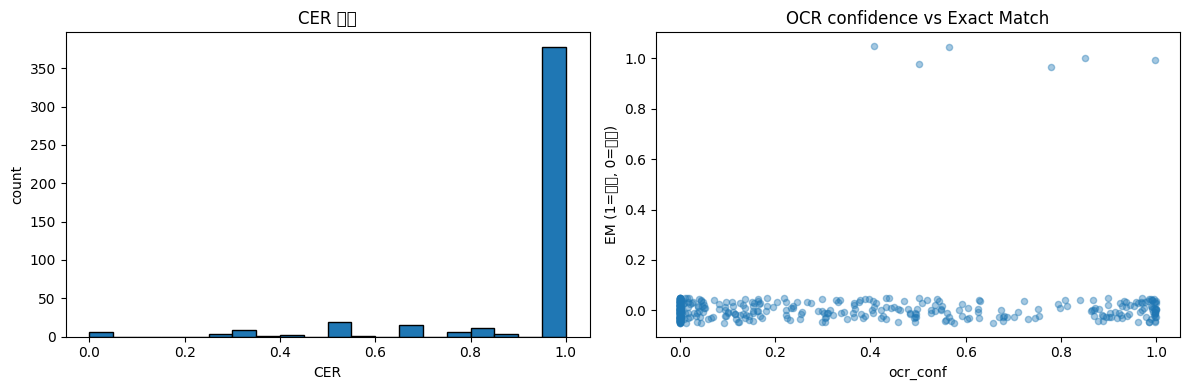


[target_text별 Exact Match 성공률]
              em_rate   n
target_text              
30           0.000000   5
4/80         0.000000   9
AJUCIT       0.000000   6
ANEDT        0.000000  17
AT50         0.000000   4
BD           0.000000   9
BD/HWP       0.000000   2
BP/R         0.000000   5
CLO          0.000000   6
D-W/LZ       0.000000   6
DACBC200     0.000000  11
E02          0.000000  10
HL145        0.000000   4
ERD          0.000000  18
HSP/213      0.000000   7
HNER         0.000000   2
KGC13        0.000000  12
JH/26        0.000000   6
HT/L50       0.000000   7
ID/U2        0.000000   1
IDPADS       0.000000  11
ID4          0.000000   7
IDS          0.000000   9
J73          0.000000   6
L24/HL       0.000000   4
KP/S5        0.000000   8
JRP/60       0.000000  12
JW3          0.000000  14
MC/S/M       0.000000   8
MMAT50       0.000000   5
MMA          0.000000  19
MJC          0.000000   5
카필러스카필러스     0.000000  16
UK/OC375     0.000000   9
WAL/15       0.000000   4
NK/15 

In [35]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # Colab 한글 폰트

# CER 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eval_results["cer"], bins=20, edgecolor="black")
axes[0].set_title("CER 분포")
axes[0].set_xlabel("CER")
axes[0].set_ylabel("count")

# OCR conf vs EM
axes[1].scatter(
    eval_results["ocr_conf"],
    eval_results["em"].astype(int) + np.random.uniform(-0.05, 0.05, len(eval_results)),
    alpha=0.4, s=20
)
axes[1].set_title("OCR confidence vs Exact Match")
axes[1].set_xlabel("ocr_conf")
axes[1].set_ylabel("EM (1=정답, 0=오답)")

plt.tight_layout()
plt.show()

# target_text별 EM
print("\n[target_text별 Exact Match 성공률]")
print(
    eval_results.groupby("target_text")["em"]
    .agg(["mean","count"])
    .rename(columns={"mean":"em_rate","count":"n"})
    .sort_values("em_rate")
    .to_string()
)
